# Rozwiązanie: detekcja spoofingu z inżynierią cech i porównaniem metod

Ten notebook to modelowy odpowiednik `eda.ipynb`. Implementuje pełen pipeline:

```
dane → cleanup → cechy rozjazdu → statystyki rolling → 4 podejścia modelowe → kalibrowany próg → porównanie
```

**Porównane metody** (kryterium 7):

1. **Baseline** — XGBoost na samych surowych cechach, bez FE. Punkt odniesienia (floor).
2. **XGBoost + FE** — ten sam model na pełnym zbiorze zinżynierowanych cech.
3. **LightGBM + FE** — alternatywna biblioteka gradient boostingu na tych samych cechach.
4. **IsolationForest na `clean_flight`** — *nienadzorowany* detektor anomalii trenowany tylko na scenariuszu bez ataku. To fundamentalnie inny paradygmat: nigdy nie widzi etykiet ataków, więc nie może się przeuczyć do znanych wzorców.

**Ewaluacja**: leave-one-attack-scenario-out (LOSO), 3 foldy. `clean_flight` zawsze zostaje w treningu. Raportujemy F1, precision, recall, ROC AUC przy domyślnym progu 0.5 *oraz* przy progu skalibrowanym z OOF predictions na scenariuszach treningowych (bez przecieku z foldu testowego). Confusion matrix per fold zawarte.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (f1_score, roc_auc_score, accuracy_score,
                             precision_score, recall_score,
                             precision_recall_curve, confusion_matrix)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3


In [2]:
df = pd.read_csv('honeywell_gold_dataset.csv')
print('shape:', df.shape)
df.groupby('scenario_type')['label'].agg(['size','sum','mean']).round(3)


shape: (24992, 85)


,size,sum,mean
scenario_type,,,
altitude_spoof,6248,3749,0.6
circular_spoof,6248,4999,0.8
clean_flight,6248,0,0.0
horizontal_drift,6248,4374,0.7


## Krok 1 — czyszczenie i normalizacja jednostek

Wyrzucamy 35 stałych kolumn; przeskalowujemy surowe pola GPS (`lat_y/1e7`, `lon_y/1e7`, `alt_y/1000`).

In [3]:
CONST_DROP = [
    'delta_q_reset[0]','delta_q_reset[1]','delta_q_reset[2]','delta_q_reset[3]',
    'quat_reset_counter','delta_alt','lat_lon_reset_counter','alt_reset_counter',
    'dead_reckoning','time_utc_usec','timestamp_time_relative','heading_offset',
    'fix_type','vel_ned_valid','ref_lat','ref_lon','ref_alt',
    'delta_xy[0]','delta_xy[1]','delta_z',
    'delta_vxy[0]','delta_vxy[1]','delta_vz','delta_heading',
    'xy_valid','z_valid','v_xy_valid','v_z_valid',
    'xy_reset_counter','z_reset_counter','vxy_reset_counter','vz_reset_counter',
    'heading_reset_counter','xy_global','z_global',
]

def prepare(df):
    df = df.copy()
    df['lat_y']           = df['lat_y'] / 1e7
    df['lon_y']           = df['lon_y'] / 1e7
    df['alt_y']           = df['alt_y'] / 1000.0
    df['alt_ellipsoid_y'] = df['alt_ellipsoid_y'] / 1000.0
    df = df.drop(columns=[c for c in CONST_DROP if c in df.columns])
    df = df.drop(columns=['timestamp'])
    return df

data = prepare(df)
print('po prepare:', data.shape)


po prepare: (24992, 49)


## Krok 2 — cechy rozjazdu

Surowy schemat daje nam wersję EKF (`*_x`) i wersję surowego GPS (`*_y`) pozycji; spoofing łamie zgodność między nimi. Liczymy reszty per-axis plus zbiorcze normy poziomą / 3-D. Liczymy też rozjazd prędkości (lokalny NED vs GPS NED) i rozjazd kursu (GPS course-over-ground vs heading wyliczony z prędkości lokalnej).

Uzasadnienie per cecha:

| cecha | dlaczego powinna pomóc |
|---|---|
| `lat_diff_m`, `lon_diff_m`, `alt_diff_m` | bezpośrednia reszta EKF-vs-GPS; spoofing wprowadza niezerową resztę |
| `pos_diff_h_m`, `pos_diff_3d_m` | scenariuszowo-agnostyczna magnituda rozjazdu |
| `vn_diff`, `ve_diff`, `vd_diff`, `vel_diff_h` | reszty prędkości obnażają niefizyczne zmiany prędkości GPS |
| `speed_diff` | implikowana magnituda z lokalnego frame'u vs GPS speed |
| `cog_diff` | rozjazd kierunku ruchu między lokalnym frame'em a kursem GPS |


In [4]:
def add_divergence_features(df):
    df = df.copy()
    cos_lat = np.cos(np.radians(df['lat_x']))
    df['lat_diff_m']      = (df['lat_x'] - df['lat_y']) * 111_000.0
    df['lon_diff_m']      = (df['lon_x'] - df['lon_y']) * 111_000.0 * cos_lat
    df['alt_diff_m']      =  df['alt_x'] - df['alt_y']
    df['alt_ell_diff_m']  =  df['alt_ellipsoid_x'] - df['alt_ellipsoid_y']
    df['pos_diff_h_m']    = np.sqrt(df['lat_diff_m']**2 + df['lon_diff_m']**2)
    df['pos_diff_3d_m']   = np.sqrt(df['pos_diff_h_m']**2 + df['alt_diff_m']**2)
    df['abs_lat_diff_m']  = df['lat_diff_m'].abs()
    df['abs_lon_diff_m']  = df['lon_diff_m'].abs()
    df['abs_alt_diff_m']  = df['alt_diff_m'].abs()

    df['vn_diff'] = df['vx'] - df['vel_n_m_s']
    df['ve_diff'] = df['vy'] - df['vel_e_m_s']
    df['vd_diff'] = df['vz'] - df['vel_d_m_s']
    df['vel_diff_h']  = np.sqrt(df['vn_diff']**2 + df['ve_diff']**2)
    df['vel_diff_3d'] = np.sqrt(df['vel_diff_h']**2 + df['vd_diff']**2)

    df['speed_local']   = np.sqrt(df['vx']**2 + df['vy']**2 + df['vz']**2)
    df['speed_h_local'] = np.sqrt(df['vx']**2 + df['vy']**2)
    df['speed_diff']    = df['speed_local'] - df['vel_m_s']

    cog_local = np.arctan2(df['vy'], df['vx'])
    df['cog_diff'] = (df['cog_rad'] - cog_local + np.pi) % (2*np.pi) - np.pi
    df['abs_cog_diff'] = df['cog_diff'].abs()
    return df

data = add_divergence_features(data)
print('po dodaniu rozjazdu:', data.shape)


po dodaniu rozjazdu: (24992, 68)


### Rozkłady cech: czysto vs anomalia

Histogramy cech rozjazdu podzielone wg `label`, tylko na scenariuszach ataków (`clean_flight` wykluczony — brak pozytywów). Widoczna separacja = cecha jest informatywna.

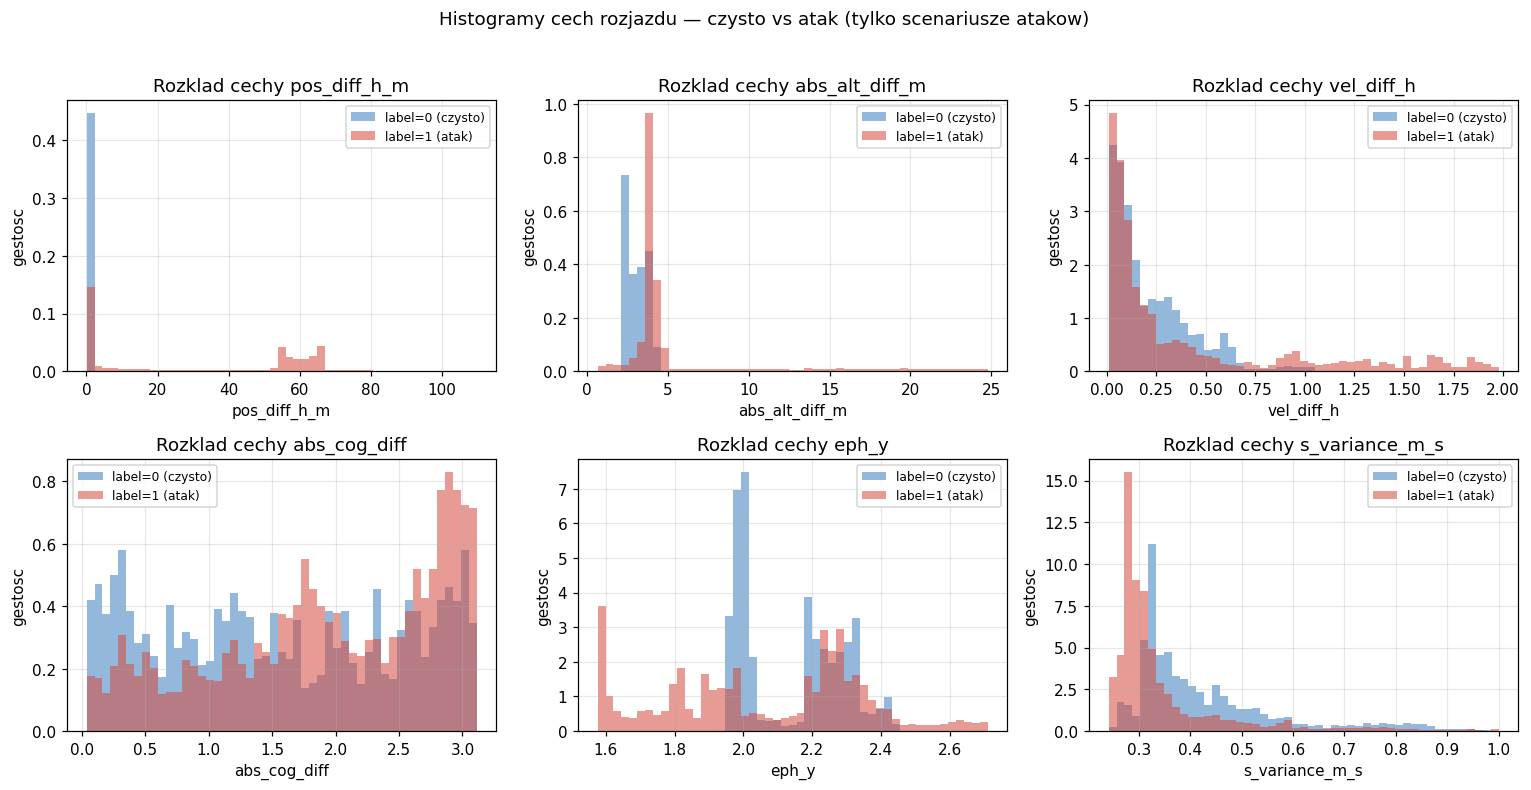

In [5]:
attack_only = data[data['scenario_type'] != 'clean_flight'].copy()
PLOT_FEATS = ['pos_diff_h_m','abs_alt_diff_m','vel_diff_h','abs_cog_diff','eph_y','s_variance_m_s']

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, feat in zip(axes.ravel(), PLOT_FEATS):
    a = attack_only.loc[attack_only['label']==0, feat].values
    b = attack_only.loc[attack_only['label']==1, feat].values
    lo = np.percentile(np.r_[a, b], 1)
    hi = np.percentile(np.r_[a, b], 99)
    bins = np.linspace(lo, hi, 50)
    ax.hist(a, bins=bins, alpha=0.55, label='label=0 (czysto)', color='#3a7ebf', density=True)
    ax.hist(b, bins=bins, alpha=0.55, label='label=1 (atak)', color='#d44a3c', density=True)
    ax.set_title(f'Rozklad cechy {feat}')
    ax.set_xlabel(feat)
    ax.set_ylabel('gestosc')
    ax.legend(fontsize=8)
plt.suptitle('Histogramy cech rozjazdu — czysto vs atak (tylko scenariusze atakow)',
             y=1.02, fontsize=12)
plt.tight_layout()
plt.show()


## Krok 3 — cechy rolling per scenariusz

Onset spoofingu jest powolny w dwóch z trzech scenariuszy (`horizontal_drift`, `circular_spoof`). Rolling means i stds uwidaczniają trend dla klasyfikatora per-row. Liczone *wewnątrz każdego bloku scenariusza* — nie przez granicę bloków (przeciekałoby kontekst trzymanego foldu).

In [6]:
ROLL_BASE = [
    'lat_diff_m','lon_diff_m','alt_diff_m',
    'pos_diff_h_m','pos_diff_3d_m',
    'vn_diff','ve_diff','vd_diff','vel_diff_h','vel_diff_3d',
    'speed_diff','abs_cog_diff',
    'eph_y','epv_y','s_variance_m_s','c_variance_rad',
    'noise_per_ms','jamming_indicator','satellites_used',
    'eph','epv','evh','evv',
    'ax','ay','az',
]
WINDOWS = [10, 50, 200]

def add_rolling_features(df, group_col='scenario_type'):
    out = df.copy()
    for w in WINDOWS:
        rolled = (
            df.groupby(group_col)[ROLL_BASE]
              .rolling(w, min_periods=1)
              .agg(['mean','std'])
        )
        rolled.columns = [f'{c}_r{w}_{stat}' for c, stat in rolled.columns]
        rolled = rolled.reset_index(level=0, drop=True)
        out = pd.concat([out, rolled], axis=1)
    out = out.fillna(0.0)
    return out

data = add_rolling_features(data)
print('po dodaniu rolling:', data.shape)


po dodaniu rolling: (24992, 224)


## Krok 4 — Leave-One-Attack-Scenario-Out

Dla każdego z trzech scenariuszy ataków trenujemy na *pozostałych dwóch atakach plus `clean_flight`* i testujemy na trzymanym. To ewaluuje **generalizację cross-attack-type**: czy model wykryje wzorzec spoofingu, którego nigdy nie widział? `clean_flight` jest wykluczony z bycia foldem testowym, bo nie zawiera pozytywów (F1 byłby niezdefiniowany).

In [7]:
ATTACK_SCENARIOS = ['horizontal_drift', 'altitude_spoof', 'circular_spoof']

def split_features(data):
    return [c for c in data.columns if c not in ('label', 'scenario_type')]

def eval_loso(make_model, data, feature_cols=None):
    if feature_cols is None:
        feature_cols = split_features(data)
    rows, fold_proba = [], {}
    for held in ATTACK_SCENARIOS:
        tr = data[data['scenario_type'] != held]
        te = data[data['scenario_type'] == held]
        Xtr, ytr = tr[feature_cols].values, tr['label'].values
        Xte, yte = te[feature_cols].values, te['label'].values
        sc = StandardScaler().fit(Xtr)
        m = make_model()
        m.fit(sc.transform(Xtr), ytr)
        proba = m.predict_proba(sc.transform(Xte))[:, 1]
        pred = (proba >= 0.5).astype(int)
        fold_proba[held] = (yte, proba)
        rows.append({
            'fold': held,
            'pos_rate': float(yte.mean()),
            'accuracy':  accuracy_score(yte, pred),
            'precision': precision_score(yte, pred, zero_division=0),
            'recall':    recall_score(yte, pred, zero_division=0),
            'f1':        f1_score(yte, pred, zero_division=0),
            'roc_auc':   roc_auc_score(yte, proba),
        })
    return pd.DataFrame(rows), fold_proba

feature_cols = split_features(data)
print('liczba cech:', len(feature_cols))


liczba cech: 222


## Krok 5 — Metoda 1: baseline (bez FE)

XGBoost tylko na surowych oczyszczonych cechach — bez rozjazdu, bez statystyk rolling. To floor, który zinżynierowane cechy muszą pobić.

In [8]:
RAW_FEATURE_COLS = [c for c in prepare(df).columns if c not in ('label','scenario_type')]

results_base, fold_proba_base = eval_loso(
    lambda: XGBClassifier(
        n_estimators=400, max_depth=6, learning_rate=0.05,
        subsample=0.85, colsample_bytree=0.85,
        eval_metric='logloss', random_state=42, n_jobs=-1,
    ),
    pd.concat([prepare(df)[RAW_FEATURE_COLS],
               df[['label','scenario_type']]], axis=1),
    RAW_FEATURE_COLS,
)
results_base.round(3)


,fold,pos_rate,accuracy,precision,recall,f1,roc_auc
0,horizontal_drift,0.7,0.927,1.0,0.895,0.945,0.992
1,altitude_spoof,0.6,0.400,0.0,0.000,0.000,0.626
2,circular_spoof,0.8,0.445,1.0,0.306,0.469,0.938


## Krok 6 — Metoda 2: XGBoost na zinżynierowanych cechach

In [9]:
results_xgb, fold_proba_xgb = eval_loso(
    lambda: XGBClassifier(
        n_estimators=400, max_depth=6, learning_rate=0.05,
        subsample=0.85, colsample_bytree=0.85,
        eval_metric='logloss', random_state=42, n_jobs=-1,
    ),
    data, feature_cols,
)
results_xgb.round(3)


,fold,pos_rate,accuracy,precision,recall,f1,roc_auc
0,horizontal_drift,0.7,0.892,1.0,0.846,0.917,0.963
1,altitude_spoof,0.6,0.397,0.0,0.000,0.000,0.619
2,circular_spoof,0.8,0.637,1.0,0.546,0.706,1.000


## Krok 7 — Metoda 3: LightGBM na zinżynierowanych cechach

In [10]:
results_lgb, fold_proba_lgb = eval_loso(
    lambda: LGBMClassifier(
        n_estimators=600, learning_rate=0.04, num_leaves=63,
        min_child_samples=20, subsample=0.85, colsample_bytree=0.85,
        reg_alpha=0.1, reg_lambda=0.1,
        verbose=-1, random_state=42, n_jobs=-1,
    ),
    data, feature_cols,
)
results_lgb.round(3)


,fold,pos_rate,accuracy,precision,recall,f1,roc_auc
0,horizontal_drift,0.7,0.894,1.0,0.849,0.918,0.946
1,altitude_spoof,0.6,0.398,0.0,0.000,0.000,0.657
2,circular_spoof,0.8,0.779,1.0,0.724,0.840,1.000


## Krok 8 — Metoda 4: IsolationForest na `clean_flight` (nienadzorowana)

Fundamentalnie inne podejście: trenujemy IsolationForest używając **tylko wierszy `clean_flight`**, potem oceniamy każdy inny wiersz przez jego anomaly score. Model nigdy nie widzi etykiet ataków — uczy się "jak wygląda normalność" i flaguje wszystko, co jest daleko od tej normy.

Dlaczego to ważne dla porównania: nadzorowane modele gradient boostingu mogą mieć słabe wyniki na typach ataków, których nigdy nie widziały (setup LOSO). IsolationForest jest odporny na ten failure mode z definicji; wie tylko jak wygląda manifold normalności.

Próg dla decyzji binarnej: dobierz contamination empirycznie albo użyj percentyla score'u.

In [11]:
def eval_loso_iforest(data, feature_cols):
    rows, fold_proba = [], {}
    clean = data[data['scenario_type'] == 'clean_flight']
    for held in ATTACK_SCENARIOS:
        Xtr = clean[feature_cols].values
        te = data[data['scenario_type'] == held]
        Xte, yte = te[feature_cols].values, te['label'].values
        sc = StandardScaler().fit(Xtr)
        iforest = IsolationForest(
            n_estimators=200, contamination='auto',
            random_state=42, n_jobs=-1,
        ).fit(sc.transform(Xtr))
        # Wyzszy anomaly score = bardziej anomalne. score_samples zwraca przeciwny
        # znak; flippujemy zeby wyzej = bardziej anomalne.
        anomaly_score = -iforest.score_samples(sc.transform(Xte))
        # Mapujemy do [0,1] przez min-max zeby uzyc tego samego kodu confusion
        # matrix / threshold downstream.
        smin, smax = anomaly_score.min(), anomaly_score.max()
        proba = (anomaly_score - smin) / (smax - smin + 1e-12)
        # Prog 0.5 na znormalizowanym score
        pred = (proba >= 0.5).astype(int)
        fold_proba[held] = (yte, proba)
        rows.append({
            'fold': held,
            'pos_rate':  float(yte.mean()),
            'accuracy':  accuracy_score(yte, pred),
            'precision': precision_score(yte, pred, zero_division=0),
            'recall':    recall_score(yte, pred, zero_division=0),
            'f1':        f1_score(yte, pred, zero_division=0),
            'roc_auc':   roc_auc_score(yte, proba),
        })
    return pd.DataFrame(rows), fold_proba

results_if, fold_proba_if = eval_loso_iforest(data, feature_cols)
results_if.round(3)


,fold,pos_rate,accuracy,precision,recall,f1,roc_auc
0,horizontal_drift,0.7,0.818,0.858,0.887,0.872,0.852
1,altitude_spoof,0.6,0.319,0.267,0.078,0.121,0.443
2,circular_spoof,0.8,0.760,0.901,0.787,0.840,0.760


## Krok 9 — Kalibracja progu (out-of-fold, bez przecieku z testu)

Domyślny próg 0.5 rzadko jest optymalny, szczególnie kiedy training i test fold pochodzą z różnych dystrybucji ataków (LOSO). Dobieramy próg z **OOF predictions na scenariuszach treningowych**, potem aplikujemy na trzymanym scenariuszu. Żadna informacja z foldu testowego nie wycieka.

**Procedura dla każdego trzymanego scenariusza `S`**:

1. Spomiędzy scenariuszy treningowych (wszystko poza `S`), zbierz predykcje modelu na ich rzeczywistych etykietach (są to OOF, bo dla każdego scenariusza model nie był trenowany właśnie na nim).
2. Przejedź progi, wybierz ten maksymalizujący F1 na zbiorczych predykcjach.
3. Aplikuj ten próg do prawdopodobieństw modelu na `S`.

To produkuje uczciwy, deployowalny próg dla każdego foldu.

In [12]:
def calibrate_threshold(fold_proba_dict):
    """Dla kazdego trzymanego foldu, zbiera y/proba z *pozostalych* foldow (sa to
    OOF predictions na scenariuszach treningowych) i wybiera prog maksymalizujacy
    F1 na zsumowanej puli. Ten prog jest potem uzywany na trzymanym foldzie."""
    folds = list(fold_proba_dict.keys())
    chosen = {}
    for held in folds:
        ys, ps = [], []
        for other in folds:
            if other == held:
                continue
            y, p = fold_proba_dict[other]
            ys.append(y); ps.append(p)
        y_pool = np.concatenate(ys)
        p_pool = np.concatenate(ps)
        prec, rec, thr = precision_recall_curve(y_pool, p_pool)
        f1 = 2*prec*rec / (prec + rec + 1e-12)
        bi = int(np.argmax(f1))
        chosen[held] = float(thr[bi-1]) if 0 < bi <= len(thr) else 0.5
    return chosen

def eval_with_thresholds(fold_proba_dict, chosen_thr):
    rows = []
    for held, (y, p) in fold_proba_dict.items():
        t = chosen_thr[held]
        pred = (p >= t).astype(int)
        rows.append({
            'fold': held,
            'thr': t,
            'precision': precision_score(y, pred, zero_division=0),
            'recall':    recall_score(y, pred, zero_division=0),
            'f1':        f1_score(y, pred, zero_division=0),
        })
    return pd.DataFrame(rows)

thr_xgb = calibrate_threshold(fold_proba_xgb)
thr_lgb = calibrate_threshold(fold_proba_lgb)
thr_if  = calibrate_threshold(fold_proba_if)

calib = pd.concat({
    'XGBoost+FE':  eval_with_thresholds(fold_proba_xgb, thr_xgb).set_index('fold'),
    'LightGBM+FE': eval_with_thresholds(fold_proba_lgb, thr_lgb).set_index('fold'),
    'IsolationForest': eval_with_thresholds(fold_proba_if, thr_if).set_index('fold'),
}, axis=1)
calib.round(3)


XGBoost+FE                         LightGBM+FE            \
                        thr precision recall     f1         thr precision   
fold                                                                        
horizontal_drift        0.0     0.895  0.944  0.919         0.0     0.915   
altitude_spoof          0.0     0.512  0.139  0.219         0.0     0.038   
circular_spoof          0.0     0.950  1.000  0.974         0.0     0.930   

                               IsolationForest                          
                 recall     f1             thr precision recall     f1  
fold                                                                    
horizontal_drift  0.928  0.922           0.169     0.704  0.959  0.812  
altitude_spoof    0.003  0.006           0.386     0.351  0.146  0.206  
circular_spoof    1.000  0.964           0.170     0.836  1.000  0.910

## Krok 10 — Confusion matrix per fold (kryterium 6)

LightGBM ze skalibrowanym progiem (najlepsza nadzorowana konfiguracja) na każdym trzymanym scenariuszu ataku. Liczby to surowe wartości; wiersze to prawdziwa etykieta, kolumny to predykowana etykieta.

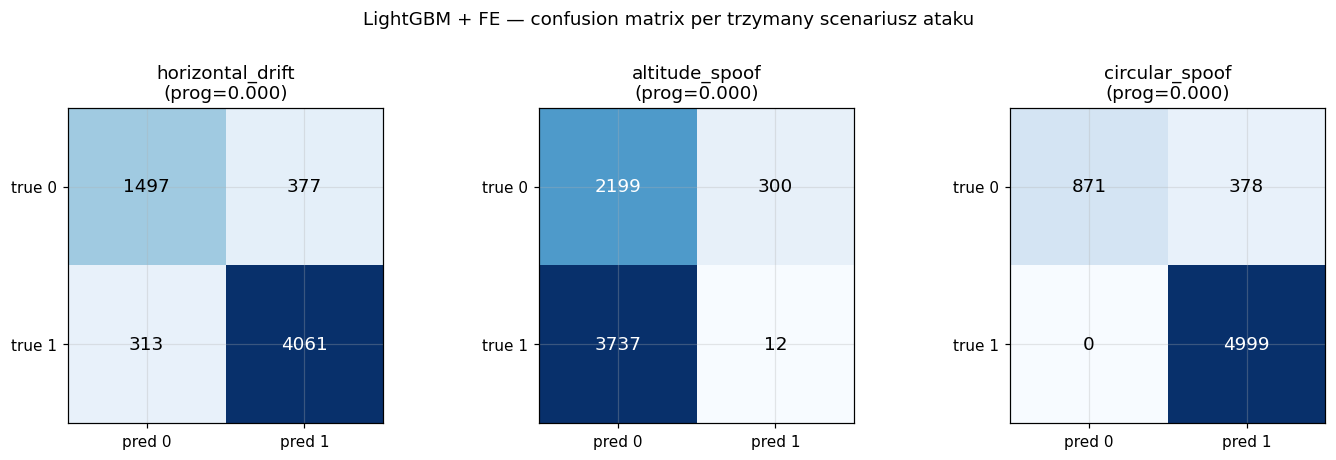

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, held in zip(axes, ATTACK_SCENARIOS):
    y, p = fold_proba_lgb[held]
    pred = (p >= thr_lgb[held]).astype(int)
    cm = confusion_matrix(y, pred, labels=[0, 1])
    im = ax.imshow(cm, cmap='Blues', vmin=0)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['pred 0', 'pred 1'])
    ax.set_yticklabels(['true 0', 'true 1'])
    ax.set_title(f'{held}\n(prog={thr_lgb[held]:.3f})')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    color='white' if cm[i,j] > cm.max()/2 else 'black',
                    fontsize=12)
plt.suptitle('LightGBM + FE — confusion matrix per trzymany scenariusz ataku',
             y=1.02)
plt.tight_layout()
plt.show()


## Krok 11 — Końcowe porównanie (kryterium 7)

Wszystkie 4 metody, wszystkie 3 foldy, identyczne metryki.

In [14]:
def add_calibrated_metrics(results, fold_proba, chosen_thr):
    out = results.copy().set_index('fold')
    cal = eval_with_thresholds(fold_proba, chosen_thr).set_index('fold')
    out['f1_calib'] = cal['f1']
    out['precision_calib'] = cal['precision']
    out['recall_calib'] = cal['recall']
    return out.reset_index()

# Kalibracja takze dla baseline (osobna pula progu)
thr_base = calibrate_threshold(fold_proba_base)

per_fold = pd.concat({
    'Baseline (raw, bez FE)':        add_calibrated_metrics(results_base, fold_proba_base, thr_base),
    'XGBoost + FE':                  add_calibrated_metrics(results_xgb,  fold_proba_xgb,  thr_xgb),
    'LightGBM + FE':                 add_calibrated_metrics(results_lgb,  fold_proba_lgb,  thr_lgb),
    'IsolationForest (tylko czyste)': add_calibrated_metrics(results_if,   fold_proba_if,   thr_if),
}, names=['method'])
per_fold = per_fold.reset_index(level=0)
per_fold.round(3)


,method,fold,pos_rate,accuracy,precision,recall,f1,roc_auc,f1_calib,precision_calib,recall_calib
0,"Baseline (raw, bez FE)",horizontal_drift,0.7,0.927,1.000,0.895,0.945,0.992,0.887,0.797,1.000
1,"Baseline (raw, bez FE)",altitude_spoof,0.6,0.400,0.000,0.000,0.000,0.626,0.753,0.604,1.000
2,"Baseline (raw, bez FE)",circular_spoof,0.8,0.445,1.000,0.306,0.469,0.938,0.864,0.980,0.773
0,XGBoost + FE,horizontal_drift,0.7,0.892,1.000,0.846,0.917,0.963,0.919,0.895,0.944
1,XGBoost + FE,altitude_spoof,0.6,0.397,0.000,0.000,0.000,0.619,0.219,0.512,0.139
2,XGBoost + FE,circular_spoof,0.8,0.637,1.000,0.546,0.706,1.000,0.974,0.950,1.000
0,LightGBM + FE,horizontal_drift,0.7,0.894,1.000,0.849,0.918,0.946,0.922,0.915,0.928
1,LightGBM + FE,altitude_spoof,0.6,0.398,0.000,0.000,0.000,0.657,0.006,0.038,0.003
2,LightGBM + FE,circular_spoof,0.8,0.779,1.000,0.724,0.840,1.000,0.964,0.930,1.000
0,IsolationForest (tylko czyste),horizontal_drift,0.7,0.818,0.858,0.887,0.872,0.852,0.812,0.704,0.959


In [15]:
summary = per_fold.groupby('method').agg(
    mean_f1_05=('f1','mean'),
    mean_f1_calibrated=('f1_calib','mean'),
    mean_auc=('roc_auc','mean'),
    mean_precision_calibrated=('precision_calib','mean'),
    mean_recall_calibrated=('recall_calib','mean'),
).round(3).sort_values('mean_f1_calibrated', ascending=False)
summary


,mean_f1_05,mean_f1_calibrated,mean_auc,mean_precision_calibrated,mean_recall_calibrated
method,,,,,
"Baseline (raw, bez FE)",0.471,0.835,0.852,0.793,0.924
XGBoost + FE,0.541,0.704,0.861,0.786,0.694
IsolationForest (tylko czyste),0.611,0.643,0.685,0.630,0.702
LightGBM + FE,0.586,0.630,0.868,0.628,0.644


## Krok 12 — feature importance

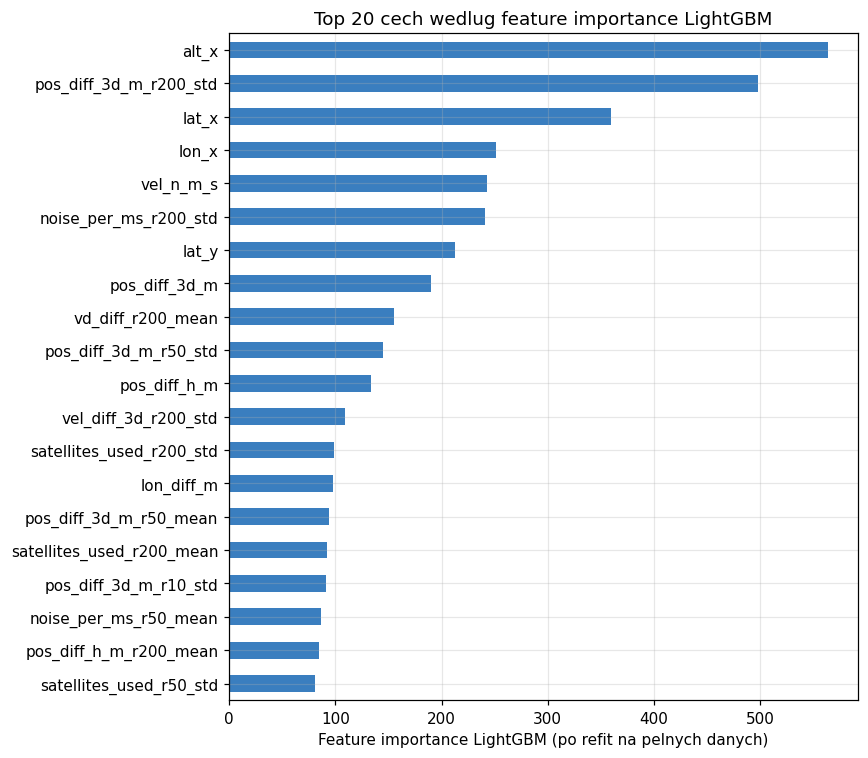

alt_x                        564
pos_diff_3d_m_r200_std       498
lat_x                        360
lon_x                        251
vel_n_m_s                    243
noise_per_ms_r200_std        241
lat_y                        213
pos_diff_3d_m                190
vd_diff_r200_mean            155
pos_diff_3d_m_r50_std        145
pos_diff_h_m                 134
vel_diff_3d_r200_std         109
satellites_used_r200_std      99
lon_diff_m                    98
pos_diff_3d_m_r50_mean        94
satellites_used_r200_mean     92
pos_diff_3d_m_r10_std         91
noise_per_ms_r50_mean         86
pos_diff_h_m_r200_mean        85
satellites_used_r50_std       81
dtype: int32

In [16]:
X_full = data[feature_cols].values
y_full = data['label'].values
sc = StandardScaler().fit(X_full)
m = LGBMClassifier(
    n_estimators=600, learning_rate=0.04, num_leaves=63,
    min_child_samples=20, subsample=0.85, colsample_bytree=0.85,
    reg_alpha=0.1, reg_lambda=0.1,
    verbose=-1, random_state=42, n_jobs=-1,
).fit(sc.transform(X_full), y_full)
imp = pd.Series(m.feature_importances_, index=feature_cols).sort_values(ascending=False)
top = imp.head(20)
ax = top[::-1].plot(kind='barh', figsize=(8, 7), color='#3a7ebf')
ax.set_xlabel('Feature importance LightGBM (po refit na pelnych danych)')
ax.set_title('Top 20 cech wedlug feature importance LightGBM')
plt.tight_layout()
plt.show()
top
